In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Đọc bảng dữ liệu bỏ qua dòng tiêu đề lớn đầu tiên
df_raw = pd.read_excel('TONG_HOP_DIEM_K58KTP.xlsx', header=1)
print("Cấu trúc bảng dữ liệu gốc sau khi đọc:")
print(df_raw.head(5))

# Trích xuất chính xác danh sách mã sinh viên tại hàng đầu tiên, từ cột thứ 3 trở đi
mssv_row = df_raw.iloc[0, 3:]
mssv_list = mssv_row.values

# Trích xuất ma trận điểm số
score_matrix = df_raw.iloc[1:, 3:].values

# Xoay bảng (Transpose) để đưa Sinh viên làm hàng và Môn học làm cột
matrix_t = score_matrix.T
df_courses = pd.DataFrame(matrix_t)
df_courses.index = mssv_list
df_courses.index.name = 'MSSV'

# Ép dữ liệu điểm về dạng số hệ số thực để tính toán
df_courses = df_courses.apply(pd.to_numeric, errors='coerce')
print("\nKích thước ma trận điểm sau khi xoay (Sinh viên x Môn học):", df_courses.shape)

Cấu trúc bảng dữ liệu gốc sau khi đọc:
  Unnamed: 0  Unnamed: 1                         MSSV        K225480106002  \
0        NaN         NaN                Tên Sinh Viên      Nguyễn Tuấn Anh   
1        STT  Mã Môn học                  Tên Môn học                  NaN   
2          1     TEE0432  Kỹ thuật lập trình nâng cao  2026-05-02 00:00:00   
3          2     TEE0591  Trí tuệ nhân tạo và học máy  2026-05-03 00:00:00   
4          3      TEE321                    Xử lý ảnh                  1.0   

     K225480106095        K225510201001 K225480106082 K225480106001  \
0  Nguyễn Tuấn Anh         Bùi Ngọc Anh   Vũ Việt Anh   Lê Tuấn Anh   
1              NaN                  NaN           NaN           NaN   
2                3                  3.0             3             3   
3                2  2026-05-02 00:00:00             3             3   
4                1                  3.0           2.5             2   

  K225480106100     K225480106008  ...   K225480106062         K2

In [10]:
df_features = pd.DataFrame(index=df_courses.index)

# 1. Tính toán điểm trung bình chung GPA toàn khóa
df_features['GPA'] = df_courses.mean(axis=1).round(2)

# 2. Thống kê tổng số môn học bị điểm dưới 2.0 của từng sinh viên
df_features['So_Mon_Duoi_2_0'] = (df_courses < 2.0).sum(axis=1)

# 3. Thống kê tổng số môn học bị điểm dưới C (< 2.5)
df_features['So_Mon_Duoi_C'] = (df_courses < 2.5).sum(axis=1)

# Điền các giá trị trống khuyết tật bằng 0
df_features.fillna(0, inplace=True)

print("Bảng đặc trưng trích xuất hoàn chỉnh:")
print(df_features.head(10))

print("\nThống kê mô tả tổng quan tập dữ liệu đặc trưng:")
print(df_features.describe())

Bảng đặc trưng trích xuất hoàn chỉnh:
                   GPA  So_Mon_Duoi_2_0  So_Mon_Duoi_C
MSSV                                                  
Nguyễn Tuấn Anh   2.28                4             14
Nguyễn Tuấn Anh   2.30               11             27
Bùi Ngọc Anh      2.19                6             16
Vũ Việt Anh       2.24               17             24
Lê Tuấn Anh       2.50               10             18
Lý Văn Cường      2.99                4              8
Nguyễn Khánh Duy  2.67                3             14
Nguyễn Thế Dương  2.70                7             15
Nguyễn Đức Dương  3.24                0              2
Đặng Đình Đạt     2.87                6             11

Thống kê mô tả tổng quan tập dữ liệu đặc trưng:
             GPA  So_Mon_Duoi_2_0  So_Mon_Duoi_C
count  71.000000        71.000000      71.000000
mean    3.496901         7.014085      14.830986
std     8.181130         5.428741       8.689872
min     0.000000         0.000000       0.000000
25%     

In [11]:
X = df_features[['GPA', 'So_Mon_Duoi_2_0', 'So_Mon_Duoi_C']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Dữ liệu sau khi chuẩn hóa phân phối (5 dòng đầu):")
print(X_scaled[:5])

Dữ liệu sau khi chuẩn hóa phân phối (5 dòng đầu):
[[-0.14980361 -0.55916048 -0.09630757]
 [-0.14734156  0.73945054  1.41033455]
 [-0.16088283 -0.18812876  0.13548353]
 [-0.15472771  1.8525457   1.06264791]
 [-0.12272106  0.55393468  0.36727462]]


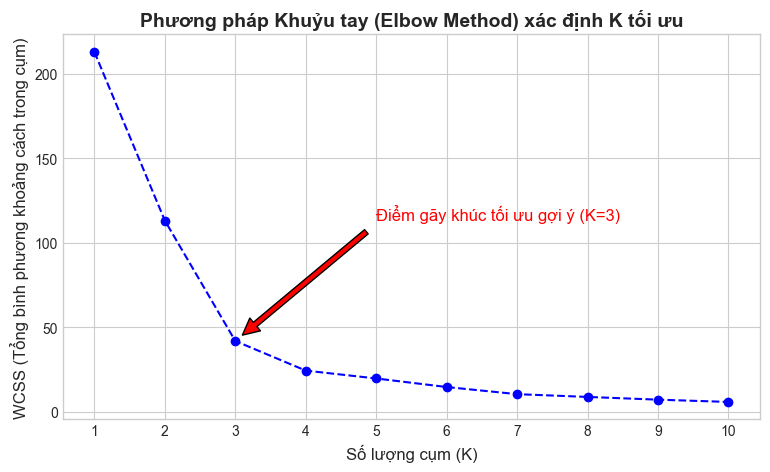

In [12]:
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Phương pháp Khuỷu tay (Elbow Method) xác định K tối ưu', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng cụm (K)', fontsize=12)
plt.ylabel('WCSS (Tổng bình phương khoảng cách trong cụm)', fontsize=12)
plt.xticks(k_range)
if len(wcss) >= 3:
    plt.annotate('Điểm gãy khúc tối ưu gợi ý (K=3)', xy=(3, wcss[2]), xytext=(5, wcss[1]),
                 arrowprops=dict(facecolor='red', shrink=0.05), fontsize=12, color='red')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled)
df_features['Cluster'] = cluster_labels

print("Số lượng sinh viên phân bổ vào từng cụm thực tế:")
print(df_features['Cluster'].value_counts())

Số lượng sinh viên phân bổ vào từng cụm thực tế:
Cluster
0    42
1    28
2     1
Name: count, dtype: int64


In [14]:
# Tính tâm cụm trung bình thực tế
cluster_profiles = df_features.groupby('Cluster')[['GPA', 'So_Mon_Duoi_2_0', 'So_Mon_Duoi_C']].mean()
print("Giá trị đặc trưng trung bình tại các tâm cụm:")
print(cluster_profiles)

# Sắp xếp động để gán nhãn không phụ thuộc vào tính ngẫu nhiên ban đầu của thuật toán
sorted_clusters = cluster_profiles.sort_values(by='GPA', ascending=False).index

cluster_mapping = {
    sorted_clusters[0]: 'An toàn',
    sorted_clusters[1]: 'Cần cải thiện',
    sorted_clusters[2]: 'Nguy cơ học lại cao'
}
df_features['Ten_Nhom'] = df_features['Cluster'].map(cluster_mapping)

recommendation_mapping = {
    'An toàn': 'Duy trì phong độ học tập hiện tại, khuyến khích tham gia nghiên cứu khoa học.',
    'Cần cải thiện': 'Tăng cường tự học nhóm, chú ý phân bổ thời gian đăng ký tín chỉ hợp lý.',
    'Nguy cơ học lại cao': 'Cần sự hỗ trợ đặc biệt từ Cố vấn học tập, lên lộ trình trả nợ môn học kịp thời.'
}
df_features['Khuyen_Nghi'] = df_features['Ten_Nhom'].map(recommendation_mapping)

print("\nKết quả phân cụm chi tiết kèm khuyến nghị (10 sinh viên đầu):")
print(df_features[['GPA', 'So_Mon_Duoi_2_0', 'So_Mon_Duoi_C', 'Ten_Nhom', 'Khuyen_Nghi']].head(10))

Giá trị đặc trưng trung bình tại các tâm cụm:
               GPA  So_Mon_Duoi_2_0  So_Mon_Duoi_C
Cluster                                           
0         2.654286         3.142857       9.047619
1         2.343214        12.785714      23.428571
2        71.190000         8.000000      17.000000

Kết quả phân cụm chi tiết kèm khuyến nghị (10 sinh viên đầu):
                   GPA  So_Mon_Duoi_2_0  So_Mon_Duoi_C             Ten_Nhom  \
MSSV                                                                          
Nguyễn Tuấn Anh   2.28                4             14        Cần cải thiện   
Nguyễn Tuấn Anh   2.30               11             27  Nguy cơ học lại cao   
Bùi Ngọc Anh      2.19                6             16        Cần cải thiện   
Vũ Việt Anh       2.24               17             24  Nguy cơ học lại cao   
Lê Tuấn Anh       2.50               10             18  Nguy cơ học lại cao   
Lý Văn Cường      2.99                4              8        Cần cải thiện   
Nguy

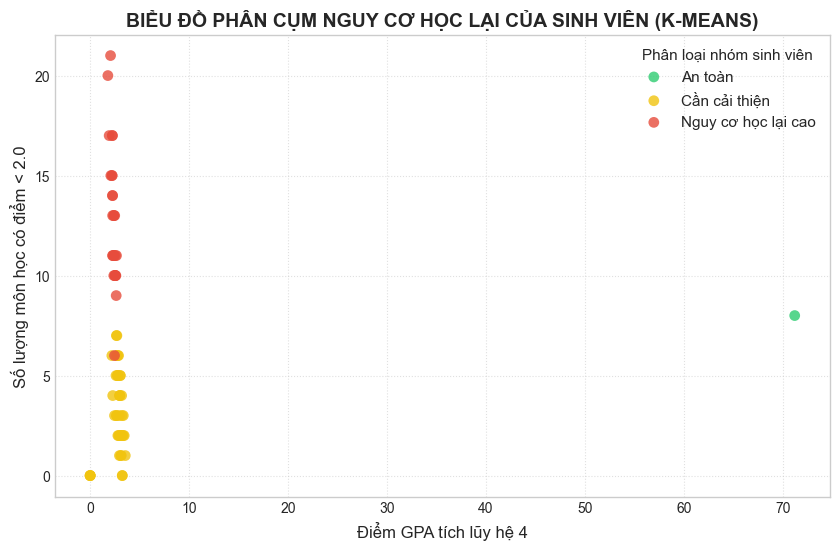

In [15]:
plt.figure(figsize=(10, 6))
colors = {'An toàn': '#2ecc71', 'Cần cải thiện': '#f1c40f', 'Nguy cơ học lại cao': '#e74c3c'}

for nhom, color in colors.items():
    sub_df = df_features[df_features['Ten_Nhom'] == nhom]
    plt.scatter(sub_df['GPA'], sub_df['So_Mon_Duoi_2_0'], 
                c=color, label=nhom, s=60, alpha=0.8, edgecolors='none')

plt.title('BIỂU ĐỒ PHÂN CỤM NGUY CƠ HỌC LẠI CỦA SINH VIÊN (K-MEANS)', fontsize=14, fontweight='bold')
plt.xlabel('Điểm GPA tích lũy hệ 4', fontsize=12)
plt.ylabel('Số lượng môn học có điểm < 2.0', fontsize=12)
plt.legend(title="Phân loại nhóm sinh viên", fontsize=11, title_fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [16]:
output_filename = 'KET_QUA_PHAN_CUM_SINH_VIEN.csv'
df_features.reset_index().rename(columns={'index': 'MSSV'}).to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"Đã xuất thành công báo cáo kết quả ra file: {output_filename}")

Đã xuất thành công báo cáo kết quả ra file: KET_QUA_PHAN_CUM_SINH_VIEN.csv
